# COVID severity prediction from basic patient features

This is a small side analysis for our project. I use the same patient-level file, but I only use basic clinical features for the model. Because the cohort is small, I treat the results as exploratory and compare every model with a simple baseline.


In [21]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import adjusted_rand_score, mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

RANDOM_STATE = 42
BROAD_PATH = Path('data/clinical_basic_features.csv')
MEXICO_PATH = Path('data/Dataset_080620_COVID19_Mexico.csv')


## 1. Broad cohort

First I load the small cohort used by the group. Controls are removed because this part is about severity among COVID-positive patients.


In [22]:
raw = pd.read_csv(BROAD_PATH)
print('Raw shape:', raw.shape)
display(raw.head())

display(raw['WHO_Score_at_Swab'].value_counts().sort_index().to_frame('count'))
display(pd.crosstab(raw['Variant_Group'], raw['WHO_Score_at_Swab']))


Raw shape: (112, 18)


,Participant,Age,Sex,BMI,Race/Ethnicity,Diabetes,HTN,CKD,Heart_Disease,Lung_Disease,Vaccine_Status,Num_Vaccine_Doses,Variant_Group,WBC,Platelets,D_Dimer,Ferritin,WHO_Score_at_Swab
0,A_COVID19_01,65,F,31.88,Black,1,1,0.0,0,0,unvaccinated,NaN,Ancestral,9.9,245.0,581,902.0,7
1,A_COVID19_02,62,M,28.79,Black,1,1,0.0,0,0,unvaccinated,NaN,Ancestral,8.5,349.0,1974,1107.0,5
2,A_COVID19_03,49,M,27.84,American Indian/Alaska Native,0,1,0.0,0,0,unvaccinated,NaN,Ancestral,7.6,153.0,1388,956.0,4
3,A_COVID19_04,63,F,26.57,Black,1,1,1.0,1,1,unvaccinated,NaN,Ancestral,11.7,201.0,4946,1020.0,4
4,A_COVID19_05,41,F,71.91,Black,1,1,0.0,0,1,unvaccinated,NaN,Ancestral,5.0,138.0,768,737.0,5


,count
WHO_Score_at_Swab,
0,27
1,4
2,1
3,15
4,22
5,19
6,9
7,15


WHO_Score_at_Swab,0,1,2,3,4,5,6,7
Variant_Group,,,,,,,,
Ancestral,0,2,0,2,5,10,5,8
Control,26,0,0,0,0,0,0,0
Delta,1,0,1,6,11,7,2,5
Omicron,0,2,0,7,6,2,2,2


COVID-positive patients: 86


,patients
High_Severity,
WHO >= 5,43
WHO < 5,43


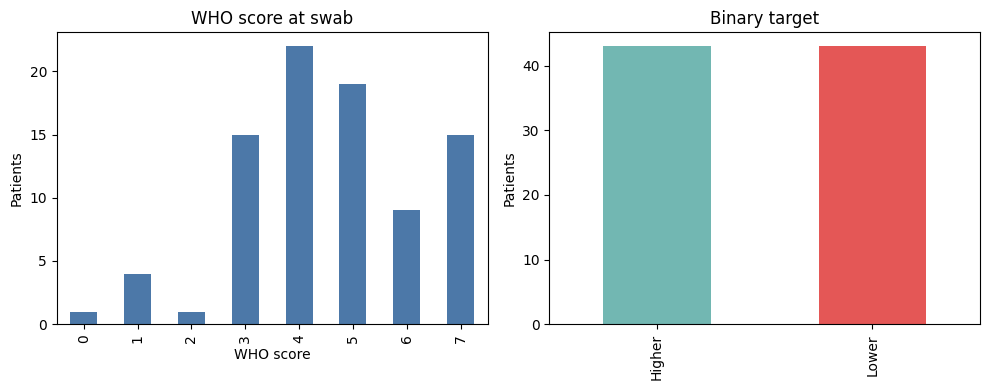

In [23]:
df = raw.copy()

for col in ['Sex', 'Race/Ethnicity', 'Vaccine_Status', 'Variant_Group']:
    df[col] = df[col].astype(str).str.strip()

def clean_number(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace('<', '')
    return pd.to_numeric(text, errors='coerce')

numeric_like = ['Age', 'BMI', 'Num_Vaccine_Doses', 'WBC', 'Platelets', 'D_Dimer', 'Ferritin']
for col in numeric_like:
    df[col] = df[col].apply(clean_number)

binary_cols = ['Diabetes', 'HTN', 'CKD', 'Heart_Disease', 'Lung_Disease']
for col in binary_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df.loc[df['Vaccine_Status'].eq('unvaccinated') & df['Num_Vaccine_Doses'].isna(), 'Num_Vaccine_Doses'] = 0

covid = df[df['Variant_Group'].ne('Control')].copy()
covid['High_Severity'] = (covid['WHO_Score_at_Swab'] >= 5).astype(int)

print('COVID-positive patients:', len(covid))
display(covid['High_Severity'].value_counts().rename(index={0: 'WHO < 5', 1: 'WHO >= 5'}).to_frame('patients'))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
covid['WHO_Score_at_Swab'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('WHO score at swab')
axes[0].set_xlabel('WHO score')
axes[0].set_ylabel('Patients')

covid['High_Severity'].map({0: 'Lower', 1: 'Higher'}).value_counts().plot(kind='bar', ax=axes[1], color=['#72B7B2', '#E45756'])
axes[1].set_title('Binary target')
axes[1].set_xlabel('')
axes[1].set_ylabel('Patients')
plt.tight_layout()
plt.show()


## 2. Classification

The target is `High_Severity`, defined as WHO score >= 5. I removed `Variant_Group` from the model features so the model is based on patient/basic clinical information, not infection wave labels.


In [24]:
target = 'High_Severity'
drop_cols = ['Participant', 'WHO_Score_at_Swab', 'Variant_Group', target]
X = covid.drop(columns=[c for c in drop_cols if c in covid.columns])
y = covid[target]

numeric_features = [
    'Age', 'BMI', 'Diabetes', 'HTN', 'CKD', 'Heart_Disease', 'Lung_Disease',
    'Num_Vaccine_Doses', 'WBC', 'Platelets', 'D_Dimer', 'Ferritin'
]
numeric_features = [c for c in numeric_features if c in X.columns]
categorical_features = [c for c in ['Sex', 'Race/Ethnicity', 'Vaccine_Status'] if c in X.columns]

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
], sparse_threshold=0)

print('Features used:', X.shape[1])
print('Numeric:', numeric_features)
print('Categorical:', categorical_features)


Features used: 15
Numeric: ['Age', 'BMI', 'Diabetes', 'HTN', 'CKD', 'Heart_Disease', 'Lung_Disease', 'Num_Vaccine_Doses', 'WBC', 'Platelets', 'D_Dimer', 'Ferritin']
Categorical: ['Sex', 'Race/Ethnicity', 'Vaccine_Status']


,model,balanced_accuracy,balanced_accuracy_std,roc_auc,roc_auc_std,f1,f1_std
2,Random forest,0.676389,0.101170,0.75679,0.085692,0.649749,0.143306
1,Logistic regression,0.652778,0.063191,0.66358,0.083510,0.667273,0.063511
0,Dummy baseline,0.500000,0.000000,0.50000,0.000000,0.256000,0.313535


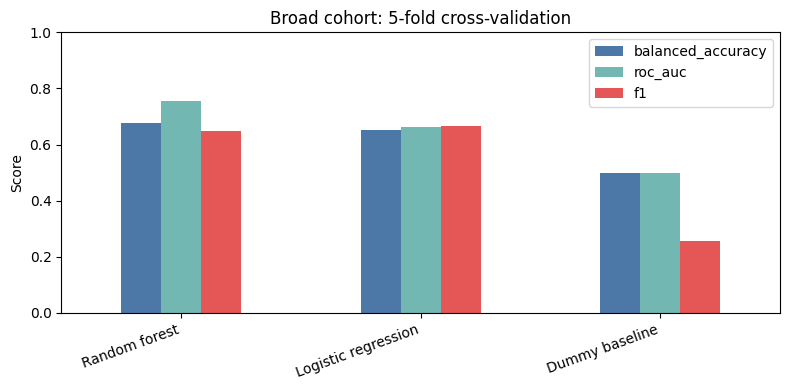

In [25]:
models = {
    'Dummy baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random forest': RandomForestClassifier(n_estimators=200, min_samples_leaf=3, class_weight='balanced', random_state=RANDOM_STATE)
}

cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'balanced_accuracy': 'balanced_accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1'}

rows = []
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])
    scores = cross_validate(pipe, X, y, cv=cv_cls, scoring=scoring)
    row = {'model': name}
    for metric in scoring:
        row[metric] = scores[f'test_{metric}'].mean()
        row[metric + '_std'] = scores[f'test_{metric}'].std()
    rows.append(row)

class_results = pd.DataFrame(rows).sort_values('balanced_accuracy', ascending=False)
display(class_results)

plot_df = class_results.set_index('model')[['balanced_accuracy', 'roc_auc', 'f1']]
plot_df.plot(kind='bar', figsize=(8, 4), ylim=(0, 1), color=['#4C78A8', '#72B7B2', '#E45756'])
plt.title('Broad cohort: 5-fold cross-validation')
plt.ylabel('Score')
plt.xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


I do not choose an "optimal" probability threshold here. A 25 percent test split would have only about 22 patients, so one threshold number can look important even when it is mostly noise. The cross-validation table is a more honest result for this dataset.


In [26]:
final_lr = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
final_lr.fit(X, y)

coefs = final_lr.named_steps['model'].coef_[0]
try:
    feature_names = final_lr.named_steps['preprocess'].get_feature_names_out()
except AttributeError:
    feature_names = [f'feature_{i}' for i in range(len(coefs))]

coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
display(coef_table.sort_values('abs_coefficient', ascending=False).head(12))


,feature,coefficient,abs_coefficient
8,num__WBC,1.058052,1.058052
7,num__Num_Vaccine_Doses,-0.795179,0.795179
0,num__Age,0.772729,0.772729
4,num__CKD,-0.467286,0.467286
16,"cat__Race/Ethnicity_White, Hispanic",0.436160,0.436160
2,num__Diabetes,0.380894,0.380894
1,num__BMI,0.357746,0.357746
17,"cat__Race/Ethnicity_White, non Hispanic",-0.267001,0.267001
11,num__Ferritin,0.263785,0.263785
15,cat__Race/Ethnicity_Black,-0.245815,0.245815


## 3. Regression and clustering checks

These are secondary checks. Regression predicts the original WHO score. Clustering asks whether patient features naturally separate into groups that match severity.


In [27]:
y_reg = covid['WHO_Score_at_Swab']
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_models = {
    'Mean baseline': DummyRegressor(strategy='mean'),
    'Ridge regression': Ridge(alpha=1.0),
    'Random forest regressor': RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE)
}

reg_rows = []
for name, model in reg_models.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])
    pred = cross_val_predict(pipe, X, y_reg, cv=cv_reg)
    reg_rows.append({
        'model': name,
        'MAE': mean_absolute_error(y_reg, pred),
        'RMSE': np.sqrt(mean_squared_error(y_reg, pred)),
        'R2': r2_score(y_reg, pred)
    })

reg_results = pd.DataFrame(reg_rows).sort_values('MAE')
display(reg_results)


,model,MAE,RMSE,R2
2,Random forest regressor,1.096590,1.385364,0.291860
1,Ridge regression,1.219237,1.515002,0.153129
0,Mean baseline,1.342339,1.664878,-0.022718


In [28]:
X_cluster = preprocess.fit_transform(X)
cluster_rows = []
for k in [2, 3, 4]:
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_cluster)
    cluster_rows.append({
        'k': k,
        'silhouette': silhouette_score(X_cluster, labels),
        'ARI_vs_severity': adjusted_rand_score(y, labels)
    })

cluster_results = pd.DataFrame(cluster_rows)
display(cluster_results)


,k,silhouette,ARI_vs_severity
0,2,0.144601,0.056284
1,3,0.124006,0.040870
2,4,0.136079,0.060066


## 4. Augmentation check

For tabular patient data, I do not treat synthetic rows as real patients. If SMOTE is available, I only use it inside the training folds as a sensitivity check and compare it with class weighting.


In [29]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

    minority_n = y.value_counts().min()
    if minority_n <= 3:
        print('SMOTE skipped because the minority class is too small.')
    else:
        smote_k = min(3, minority_n - 1)
        smote_models = {
            'Class weighting': Pipeline([
                ('preprocess', preprocess),
                ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
            ]),
            'SMOTE inside CV': ImbPipeline([
                ('preprocess', preprocess),
                ('smote', SMOTE(k_neighbors=smote_k, random_state=RANDOM_STATE)),
                ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
            ])
        }

        smote_rows = []
        for name, pipe in smote_models.items():
            scores = cross_validate(pipe, X, y, cv=cv_cls, scoring=scoring)
            smote_rows.append({
                'model': name,
                'balanced_accuracy': scores['test_balanced_accuracy'].mean(),
                'roc_auc': scores['test_roc_auc'].mean(),
                'f1': scores['test_f1'].mean()
            })
        display(pd.DataFrame(smote_rows))
except ImportError:
    print('imbalanced-learn is not installed, so I skipped the optional SMOTE check.')


,model,balanced_accuracy,roc_auc,f1
0,Class weighting,0.652778,0.663580,0.667273
1,SMOTE inside CV,0.652778,0.669136,0.667273


## 5. Mexico benchmark

The Mexico file is a separate real-patient dataset. It is useful as a comparison for clinical-feature prediction, but it is not the same as the single-cell/genetic dataset.


In [30]:
def detect_delimiter(path):
    with path.open('r', encoding='utf-8', errors='ignore') as f:
        sample = f.read(4096)
    try:
        return csv.Sniffer().sniff(sample, delimiters=',;	').delimiter
    except csv.Error:
        first = sample.splitlines()[0]
        return ';' if first.count(';') > first.count(',') else ','

def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

def yes_no_to_binary(series):
    return series.astype(str).str.strip().map({'1': 1, '2': 0})

if not MEXICO_PATH.exists():
    print('Mexico file not found:', MEXICO_PATH)
else:
    sep = detect_delimiter(MEXICO_PATH)
    all_cols = pd.read_csv(MEXICO_PATH, sep=sep, nrows=0).columns

    column_map = {
        'sex': first_existing(all_cols, ['SEXO', 'sex']),
        'age': first_existing(all_cols, ['EDAD', 'age']),
        'death': first_existing(all_cols, ['FALLECIO', 'death']),
        'intubated': first_existing(all_cols, ['INTUBADO', 'intubated']),
        'icu': first_existing(all_cols, ['UCI', 'icu']),
        'pneumonia': first_existing(all_cols, ['NEUMONIA', 'pneumonia']),
        'diabetes': first_existing(all_cols, ['DIABETES', 'diabetes']),
        'copd': first_existing(all_cols, ['EPOC', 'copd']),
        'asthma': first_existing(all_cols, ['ASMA', 'asthma']),
        'immunosuppression': first_existing(all_cols, ['INMUSUPR', 'immunosuppression']),
        'hypertension': first_existing(all_cols, ['HIPERTENSION', 'hypertension']),
        'cardiovascular': first_existing(all_cols, ['CARDIOVASCULAR', 'cardiovascular']),
        'obesity': first_existing(all_cols, ['OBESIDAD', 'obesity']),
        'chronic_kidney': first_existing(all_cols, ['RENAL_CRONICA', 'chronic_kidney']),
        'smoking': first_existing(all_cols, ['TABAQUISMO', 'smoking']),
        'other_comorbidity': first_existing(all_cols, ['OTRA_COM', 'other_comorbidity']),
        'result': first_existing(all_cols, ['RESULTADO', 'RESULTADO_LAB', 'CLASIFICACION_FINAL', 'result'])
    }

    usecols = sorted({v for v in column_map.values() if v is not None})
    mex = pd.read_csv(MEXICO_PATH, sep=sep, usecols=usecols, low_memory=False)
    mex = mex.rename(columns={v: k for k, v in column_map.items() if v is not None})

    if 'result' in mex.columns:
        mex = mex[mex['result'].astype(str).str.strip().eq('1')].copy()

    target_parts = []
    for col in ['death', 'icu', 'intubated']:
        if col in mex.columns:
            target_parts.append(yes_no_to_binary(mex[col]).fillna(0).astype(int))

    mex['severe_outcome'] = np.maximum.reduce(target_parts)
    print('Mexico confirmed COVID patients:', len(mex))
    display(mex['severe_outcome'].value_counts().rename(index={0: 'not severe', 1: 'severe'}).to_frame('patients'))


Mexico confirmed COVID patients: 146681


,patients
severe_outcome,
not severe,121544
severe,25137


In [31]:
if MEXICO_PATH.exists():
    mex_features = [
        'age', 'sex', 'pneumonia', 'diabetes', 'copd', 'asthma', 'immunosuppression',
        'hypertension', 'other_comorbidity', 'cardiovascular', 'obesity', 'chronic_kidney', 'smoking'
    ]
    mex_features = [c for c in mex_features if c in mex.columns]
    model_mex = mex[mex_features + ['severe_outcome']].copy()

    model_mex['age'] = pd.to_numeric(model_mex['age'], errors='coerce')
    for col in [c for c in mex_features if c not in ['age', 'sex']]:
        model_mex[col] = yes_no_to_binary(model_mex[col])
    model_mex['sex'] = model_mex['sex'].astype(str).str.strip().map({'1': 'female', '2': 'male'})

    X_mex = model_mex.drop(columns=['severe_outcome'])
    y_mex = model_mex['severe_outcome'].astype(int)

    preprocess_mex = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), ['age']),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), [c for c in X_mex.columns if c != 'age'])
    ], sparse_threshold=0)

    mex_models = {
        'Dummy baseline': DummyClassifier(strategy='most_frequent'),
        'Logistic regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    }

    cv_mex = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    mex_rows = []
    for name, model in mex_models.items():
        pipe = Pipeline([('preprocess', preprocess_mex), ('model', model)])
        scores = cross_validate(pipe, X_mex, y_mex, cv=cv_mex, scoring=scoring, n_jobs=-1)
        mex_rows.append({
            'model': name,
            'balanced_accuracy': scores['test_balanced_accuracy'].mean(),
            'roc_auc': scores['test_roc_auc'].mean(),
            'f1': scores['test_f1'].mean()
        })

    mexico_results = pd.DataFrame(mex_rows).sort_values('balanced_accuracy', ascending=False)
    display(mexico_results)


,model,balanced_accuracy,roc_auc,f1
1,Logistic regression,0.804292,0.877602,0.585715
0,Dummy baseline,0.500000,0.500000,0.000000


## Short conclusion

The broad cohort analysis is a small clinical-feature prediction test, not proof of a genetic mechanism. I avoid making artificial patients the main result. The most defensible comparison is: basic clinical features give an exploratory prediction signal, while the gene-level analysis is better suited for biological interpretation and follow-up research.
